# 02 Tail dependence

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/02_tail_dependence.ipynb)

**The question.** Notebook 01 matched every moment and every correlation of six
ETFs and still missed the tails of two portfolios: equity markets that fall
together more than they rise together, and equity and bonds whose large moves
coincide in either direction. What is that property, how is it measured in a
history, and how does it become a target?

**The answer in one paragraph.** A joint distribution is its marginals plus a
*copula*, the dependence stripped of the marginals. The generator of notebook
01 had a Gaussian copula, which has one number per pair, the correlation, and
no tail behaviour. Other copula families put dependence in the tails, with a
direction (Clayton, Gumbel) or without (Student t), and the exceedance profile
of a pair says which. The second generator selects a family per pair from the
history, tests first whether the profile's asymmetry is real or sampling noise,
calibrates the parameters to the target correlations, and matches the same
moments as before. Targets, fit, check, use, again, with the tails in the
targets this time.

**What you need before this notebook.** Notebook 01: the targets, the four
steps, the exceedance correlation.

**What this notebook adds.** Copulas and tail dependence; the exceedance
profile as a measurement; the families and their tail coefficients; the
symmetry test; the C-vine generator; the two portfolios of notebook 01 with
their tails recovered where the data identify them.

Runtime: about 10 minutes (the selection-noise simulation and the calibration
on six assets take most of it).

## Import

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import (load_etf_monthly, Targets, FleishmanMarket, CVineMarket, exceedance_curve,
                            classify_pair, select_family, tail_asymmetry_test)
from scipy import stats
import pyvinecopulib as pv

cvinemarketgen 0.3.0


## The history, the targets and the benchmark

The same six ETFs, the same targets, and the generator of notebook 01 refitted
as the benchmark: every comparison below is against it.

In [2]:
X = load_etf_monthly(["SPY", "IWM", "EFA", "TLT", "IEF", "GLD"], start="2004-12", cache=os.path.join(ROOT, "data", "etf_cache_course.csv"))
t = Targets.from_history(X)
fm = FleishmanMarket(t).fit(); S = fm.simulate(25000, seed=1)
print(X.shape[0], "months |", fm, "| benchmark draw", S.shape)

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_course.csv: 261 months, 2005-01 to 2026-09
261 months | FleishmanMarket(6 assets, fitted) | benchmark draw (25000, 6)


## Marginals and copula

Sklar's theorem: any joint distribution $F$ of $N$ variables with continuous
marginals $F_1, \dots, F_N$ can be written

$$
F(x_1, \dots, x_N) = C\big(F_1(x_1), \dots, F_N(x_N)\big),
$$

where $C$, the copula, is a joint distribution on $[0,1]^N$ with uniform
marginals, and it is unique. The variables $U_i = F_i(X_i)$ are uniform
whatever $F_i$ is, so $C$ is the dependence with the marginals removed: the
skewness and kurtosis of notebook 01 are in the $F_i$, the way the assets move
together is in $C$. In notebook 01 the marginals were Fleishman cubics and the
copula was Gaussian, the copula of a multivariate normal, without anyone
choosing it: mixing the assets through correlated normals imposes it. A
Gaussian copula is determined by its correlations and has no tails: given that
one variable is in its far tail, the other is no more likely to be in its own
tail than a correlation implies.

The empirical copula of a pair is seen by ranking: $\hat U_{i,t} = \mathrm{rank}(r_{i,t}) / (n + 1)$
replaces each return by its position in its own sample. The plot shows the
ranks of SPY against EFA in the history, and the same for a draw from a
Gaussian copula with the same correlation. Read the corners: the history piles
points in the lower-left corner (both in their worst months) more than in the
upper-right; the Gaussian copula is symmetric, and thinner in both corners.

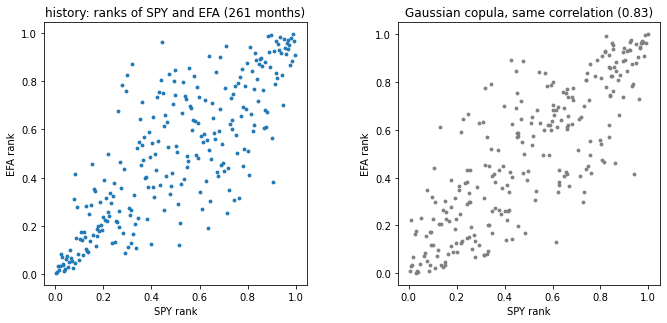

share of months in the lower-left corner (both below their 10% quantile) divided by 10%, and the same upper-right:
  history 0.84 / 0.65   Gaussian copula 0.50 / 0.65


In [3]:
U = pd.DataFrame({c: stats.rankdata(X[c]) / (len(X) + 1) for c in X.columns}, index=X.index)     # empirical copula (pseudo-observations)
rho = np.corrcoef(stats.norm.ppf(U["SPY"]), stats.norm.ppf(U["EFA"]))[0, 1]
G = pv.Bicop(pv.BicopFamily.gaussian, 0, parameters=np.array([[rho]])).simulate(len(X), seeds=[1, 2, 3, 4, 5])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].scatter(U["SPY"], U["EFA"], s=8); axes[0].set_title(f"history: ranks of SPY and EFA ({len(X)} months)")
axes[1].scatter(G[:, 0], G[:, 1], s=8, color="tab:grey"); axes[1].set_title(f"Gaussian copula, same correlation ({rho:.2f})")
for ax in axes: ax.set_xlabel("SPY rank"); ax.set_ylabel("EFA rank"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
corner = lambda u, v, q: (np.mean((u <= q) & (v <= q)) / q, np.mean((u > 1 - q) & (v > 1 - q)) / q)
print("share of months in the lower-left corner (both below their 10% quantile) divided by 10%, and the same upper-right:")
print("  history %.2f / %.2f   Gaussian copula %.2f / %.2f" % (*corner(U["SPY"].values, U["EFA"].values, 0.10), *corner(G[:, 0], G[:, 1], 0.10)))

## Tail dependence with a direction

The corner counts above are estimates of the tail-dependence coefficients,

$$
\lambda_L = \lim_{q \to 0} \Pr\big(U_2 \le q \mid U_1 \le q\big) = \lim_{q \to 0} \frac{C(q, q)}{q}, \qquad
\lambda_U = \lim_{q \to 1} \Pr\big(U_2 > q \mid U_1 > q\big) = \lim_{q \to 1} \frac{1 - 2q + C(q, q)}{1 - q},
$$

the probability that one variable is in its extreme tail given that the other
is. For the Gaussian copula both are zero whatever the correlation. Two
one-parameter families put mass in one corner: the Clayton copula
$C(u, v) = (u^{-\theta} + v^{-\theta} - 1)^{-1/\theta}$ has
$\lambda_L = 2^{-1/\theta}$ and $\lambda_U = 0$; the Gumbel copula
$C(u, v) = \exp\{-[(-\ln u)^\theta + (-\ln v)^\theta]^{1/\theta}\}$ has
$\lambda_U = 2 - 2^{1/\theta}$ and $\lambda_L = 0$. Rotating a copula by 180
degrees, $C_{180}(u, v) = u + v - 1 + C(1 - u, 1 - v)$, swaps its corners; 90
and 270 degrees turn positive dependence into negative. So the catalog covers
each corner with a positive or negative sign.

The exceedance-correlation profile of notebook 01 is the finite-sample view of
the same thing: a copula with $\lambda_L > 0$ and $\lambda_U = 0$ has a profile
that is higher on the left than on the right. The table fits each family to
the ranks of SPY and EFA by maximum likelihood and gives its log-likelihood,
its BIC and the tail coefficients it implies. Read it against the plot above:
the families with a lower-tail coefficient fit better than the Gaussian, the
one with an upper-tail coefficient worse.

In [4]:
pair = U[["SPY", "EFA"]].values
rows = {}
for fam, rot, label in [(pv.BicopFamily.gaussian, 0, "Gaussian"), (pv.BicopFamily.clayton, 0, "Clayton (lower tail)"), (pv.BicopFamily.gumbel, 180, "Gumbel 180 (lower tail)"),
                        (pv.BicopFamily.gumbel, 0, "Gumbel (upper tail)"), (pv.BicopFamily.clayton, 180, "Clayton 180 (upper tail)"), (pv.BicopFamily.student, 0, "Student t (both tails)")]:
    b = pv.Bicop(fam, rot); b.fit(pair); th = b.parameters.ravel()
    lam_L = lam_U = 0.0
    if fam == pv.BicopFamily.clayton: lam = 2 ** (-1 / th[0]); lam_L, lam_U = (lam, 0.0) if rot == 0 else (0.0, lam)
    if fam == pv.BicopFamily.gumbel: lam = 2 - 2 ** (1 / th[0]); lam_L, lam_U = (0.0, lam) if rot == 0 else (lam, 0.0)
    if fam == pv.BicopFamily.student: r_, nu = th; lam_L = lam_U = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - r_) / (1 + r_)), nu + 1)
    rows[label] = {"parameters": ", ".join(f"{v:.2f}" for v in th), "log-likelihood": b.loglik(pair), "BIC": b.bic(pair), "lambda_L": lam_L, "lambda_U": lam_U}
pd.DataFrame(rows).T

,parameters,log-likelihood,BIC,lambda_L,lambda_U
Gaussian,0.84,154.269741,-302.974961,0.0,0.0
Clayton (lower tail),2.76,152.125481,-298.686441,0.777652,0.0
Gumbel 180 (lower tail),2.72,163.72183,-321.879139,0.709732,0.0
Gumbel (upper tail),2.44,135.210896,-264.857272,0.0,0.671565
Clayton 180 (upper tail),2.14,103.20572,-200.846919,0.0,0.722833
Student t (both tails),"0.83, 5.00",156.19047,-301.251899,0.485203,0.485203


## Tail dependence without a direction

Equity and Treasuries showed no asymmetry in notebook 01 and a co-kurtosis of
1.75 against the Gaussian's 1.02: their large moves coincide, in either
direction. The family for that is the Student t copula, the copula of a
bivariate $t$ distribution with correlation $\rho$ and $\nu$ degrees of
freedom. It is symmetric, and both tail coefficients equal

$$
\lambda_L = \lambda_U = 2\, t_{\nu + 1}\!\left( -\sqrt{\frac{(\nu + 1)(1 - \rho)}{1 + \rho}} \right),
$$

positive even at $\rho = 0$ and falling to the Gaussian's zero as
$\nu \to \infty$. It has two parameters where the other families have one:
$\rho$ plays the role of the correlation and is calibrated to the target like
every other family's parameter; $\nu$ is estimated from the history and sets
how much the sizes of the moves co-move. The table fits the Gaussian and the
Student t to the ranks of SPY and TLT, and simulates each with the assets'
Johnson SU marginals of the paper to show the co-kurtosis it produces against
the history's.

In [5]:
from cvinemarketgen import fit_johnson_su
pair = U[["SPY", "TLT"]].values
def jsu_q(asset, u):
    p = fit_johnson_su(t.skew[asset], t.kurt[asset]); z = stats.norm.ppf(u)
    return t.mean[asset] + t.vol[asset] * (p["xi"] + p["lambda"] * np.sinh((z - p["gamma"]) / p["delta"]))
z_ = lambda v: (v - v.mean()) / v.std()
rows = {"history": {"parameters": "", "log-likelihood": np.nan, "BIC": np.nan, "lambda": np.nan, "co-kurtosis E[s^2 b^2]": np.mean(z_(X["SPY"])**2 * z_(X["TLT"])**2)}}
for fam, label in [(pv.BicopFamily.gaussian, "Gaussian"), (pv.BicopFamily.student, "Student t")]:
    b = pv.Bicop(fam, 0); b.fit(pair); th = b.parameters.ravel()
    lam = 0.0 if fam == pv.BicopFamily.gaussian else 2 * stats.t.cdf(-np.sqrt((th[1] + 1) * (1 - th[0]) / (1 + th[0])), th[1] + 1)
    V = b.simulate(100000, seeds=[1, 2, 3, 4, 5]); s_, b_ = z_(jsu_q("SPY", V[:, 0])), z_(jsu_q("TLT", V[:, 1]))
    rows[label] = {"parameters": ", ".join(f"{v:.2f}" for v in th), "log-likelihood": b.loglik(pair), "BIC": b.bic(pair), "lambda": lam, "co-kurtosis E[s^2 b^2]": np.mean(s_**2 * b_**2)}
pd.DataFrame(rows).T

,parameters,log-likelihood,BIC,lambda,co-kurtosis E[s^2 b^2]
history,,NaN,NaN,NaN,1.750084
Gaussian,-0.08,0.746196,4.072128,0.0,1.022805
Student t,"-0.08, 2.78",9.744138,-8.359235,0.107847,2.248656


## Selecting the family from the data, and the noise problem

The paper's selection rule (Algorithm 3 of Section 4.5.4) reads the exceedance
profile on thresholds from $-0.5$ to $0.5$ standard deviations and classifies
the pair by four characteristics: $\ell = 1$ if the profile is higher on the
left, $u = 1$ if higher on the right, $s$ the sign of the target correlation,
$m = -1$ if the profile changes sign. The families whose tail coefficients
match the class are fitted, and the one with the lowest BIC is kept; a
sign-changing pair gets a two-component mixture $w\,C_1 + (1 - w)\,C_2$.

The profile is estimated, and on 260 months it is noisy: the conditional
correlation at $z = -1$ uses the months where the central asset is below minus
one standard deviation, about 40 of them, with a standard error near 0.15. The
first cell measures the consequence on pairs simulated from a Gaussian copula,
which have no tails and no asymmetry by construction: the share of them the
rule classifies as asymmetric or sign-changing, at the ETF sample size, for
two correlations.

One more thing changes from the paper. Its first tree read the profile on the
standardized returns; a profile on returns slopes with the skewness of the
conditioning variable whatever the copula (a longer left tail has a larger
conditional variance, hence a higher correlation there), so marginal skewness
was read as copula asymmetry. The classification and the test below are
computed on the *normal scores* of the two series, $\Phi^{-1}(\mathrm{rank}/(n+1))$,
the copula scale on which the deeper trees of the vine already worked: only
the dependence is read.

The remedy for the noise is a test before the classification. The statistic is the mean of
the profile on the left minus its mean on the right,
$\bar\rho_L - \bar\rho_R$, on thresholds from $-1$ to $1$ standard deviations
(the range of the figures; the classification's own window, $-0.5$ to $0.5$,
gives the test too many false asymmetries); its sampling distribution comes from resampling
the observations with replacement (500 resamples); when zero lies inside the
central 90 percent interval the asymmetry is not distinguishable from noise,
the pair is *symmetric*, and the candidates are the Gaussian and the Student t
by BIC. Otherwise the classification applies as before. The second cell runs
the test on SPY against EFA and on SPY against TLT.

In [6]:
rng = np.random.default_rng(0); n = len(X)
rows = {}
for rho_ in (-0.09, 0.60):
    asym_flags = 0; mix_flags = 0; fams_old = {}; fams_new = {}
    for k in range(40):
        z = rng.multivariate_normal([0, 0], [[1, rho_], [rho_, 1]], size=n)
        c = classify_pair(z[:, 0], z[:, 1]); asym_flags += (c["l"] or c["u"]); mix_flags += (c["m"] == -1)
        for label, sel in [("paper's rule", select_family(z[:, 0], z[:, 1], symmetry_test=False)), ("with the symmetry test", select_family(z[:, 0], z[:, 1]))]:
            d = fams_old if label == "paper's rule" else fams_new; f = sel["family"] if sel["status"] == "ordinary" else "mixture"; d[f] = d.get(f, 0) + 1
    rows[f"Gaussian pairs, rho = {rho_:+.2f}"] = {"classified asymmetric (%)": asym_flags / 40 * 100, "classified sign-changing (%)": mix_flags / 40 * 100,
                                                 "paper's rule: Gaussian (%)": fams_old.get("gaussian", 0) / 40 * 100, "with the test: Gaussian or Student (%)": (fams_new.get("gaussian", 0) + fams_new.get("student", 0)) / 40 * 100}
print(f"40 simulated Gaussian pairs of {n} observations per row")
pd.DataFrame(rows).T.round(0)

40 simulated Gaussian pairs of 261 observations per row


,classified asymmetric (%),classified sign-changing (%),paper's rule: Gaussian (%),with the test: Gaussian or Student (%)
"Gaussian pairs, rho = -0.09",78.0,80.0,2.0,88.0
"Gaussian pairs, rho = +0.60",75.0,0.0,25.0,88.0


In [7]:
rows = {}
for b in ["EFA", "IWM", "TLT", "GLD"]:
    r = tail_asymmetry_test(X["SPY"], X[b])
    rows[f"SPY, {b}"] = {"mean left minus mean right": r["difference"], "bootstrap 5%": r["lower"], "bootstrap 95%": r["upper"], "symmetric": r["symmetric"]}
pd.DataFrame(rows).T.round(3)

,mean left minus mean right,bootstrap 5%,bootstrap 95%,symmetric
"SPY, EFA",0.16182,0.044986,0.288832,False
"SPY, IWM",0.111507,0.019005,0.227924,False
"SPY, TLT",-0.000781,-0.241133,0.244848,True
"SPY, GLD",0.024207,-0.220867,0.279343,True


## Step 2 again: the C-vine generator

With $N$ assets there are $N(N-1)/2$ pairs, and a set of pair copulas is not
automatically a valid joint copula. The C-vine (canonical vine) makes it one:
with asset 1 as the central node, the joint density factorises into
$N - 1$ pair copulas of asset 1 with each other asset (tree 1), then pair
copulas of the remaining assets given asset 1 (tree 2), and so on,

$$
c(u_1, \dots, u_N) = \prod_{k=1}^{N-1} \prod_{i=k+1}^{N} c_{ik \mid 1:k-1}\big(F(u_i \mid u_{1:k-1}),\, F(u_k \mid u_{1:k-1})\big),
$$

every factor a bivariate copula chosen and fitted on its own, the conditional
arguments computed by the $h$-functions $h(u \mid v; \theta) = \partial C(u, v; \theta) / \partial v$
of the previous tree. The families are selected tree by tree as in the previous
section (Algorithm 3), with the symmetry test on each pair. The parameters are
then *calibrated*, not left at their history values: for $i = 2, \dots, N$ the
parameters of the edges of asset $i$ solve

$$
\hat{\boldsymbol\theta}_i = \arg\min_{\boldsymbol\theta_i} \sum_{k < i} \Big( \mathrm{Corr}\big(F_i^{-1}(u_i(\boldsymbol\theta_i)),\, F_k^{-1}(u_k)\big) - \Sigma^*_{ik} \Big)^2
$$

on a fixed set of simulated uniforms (Algorithm 4), so the Pearson correlations
of the output are the targets while the families keep the tails. The marginals
$F_i^{-1}$ are Johnson SU quantiles fitted to the four moments (Section 4.3),
the paper's choice in place of the Fleishman cubic; the acceptance rule is
that of notebook 01 with a correlation tolerance of 0.05. `fit` runs the three
algorithms; `classification` shows the test and the class of each first-tree
pair; `edges` the family and calibrated parameters of every edge. SPY is the
central node, the asset that drives the others.

In [8]:
t0 = time.time()
cv = CVineMarket(t, central="SPY", families="auto").fit()
print(f"fit: {time.time() - t0:.0f} s |", cv)
cv.classification.round(3)

fit: 193 s | CVineMarket(6 assets, fitted)


,symmetric,asymmetry,asymmetry_lower,asymmetry_upper,lower_tail_dependence,upper_tail_dependence,target_correlation_sign,monotone_dependence
pair with SPY,,,,,,,,
IWM,False,0.111507,0.019005,0.227924,True,False,1.0,1.0
EFA,False,0.16182,0.044986,0.288832,True,False,1.0,1.0
TLT,True,-0.000781,-0.241133,0.244848,False,False,-11,1
IEF,True,-0.025176,-0.261512,0.209451,False,False,-11,1
GLD,True,0.024207,-0.220867,0.279343,False,False,-11,1


In [9]:
pd.set_option("display.max_colwidth", 60)
cv.edges

,tree,edge,selected family,parameters
0,1,"IWM , SPY",gumbel 180°,theta=3.281
1,1,"EFA , SPY",gumbel 180°,theta=2.837
2,1,"TLT , SPY",student 0°,"rho=-0.106, df=2.8"
3,1,"IEF , SPY",student 0°,"rho=-0.087, df=2.7"
4,1,"GLD , SPY",gaussian 0°,theta=0.082
5,2,"EFA , IWM | SPY",gaussian 0°,theta=0.057
6,2,"TLT , IWM | SPY",student 0°,"rho=-0.129, df=4.1"
7,2,"IEF , IWM | SPY",student 0°,"rho=-0.134, df=5.3"
8,2,"GLD , IWM | SPY",gaussian 0°,theta=-0.072
9,3,"TLT , EFA | SPY, IWM",student 0°,"rho=0.075, df=3.6"


Read the first tree. The two equity pairs are the ones the test finds
asymmetric on the copula scale (SPY with EFA 0.16, interval $[0.04, 0.29]$;
SPY with IWM 0.11, $[0.02, 0.23]$) and both receive a Gumbel rotated by 180
degrees, lower-tail dependence: developed markets and small caps fall with
U.S. large caps more than they rise with them. The Treasury pairs receive the
Student t, the co-movement of sizes with no direction (2.8 and 2.7 degrees of
freedom); gold a Gaussian. The deeper trees carry the dependence that remains
once SPY is accounted for, most of it weak, with a Gumbel between the two
Treasury funds given the equities.

## Step 3: check

The check of notebook 01 first: the moments and the correlations, matched by
construction. Then the check this notebook is about: the exceedance profile of
SPY against each other asset, the history in black, the benchmark in grey, the
C-vine in blue, and the same at three thresholds in a table.

In [10]:
C = cv.simulate(25000, seed=1)
cv.diagnostics(C)

Diagnostics(n=25000, max |corr error|=0.0114, mean 1.2e-09, vol 1.1e-06, skew 3.3e-05, kurt 6.0e-04)

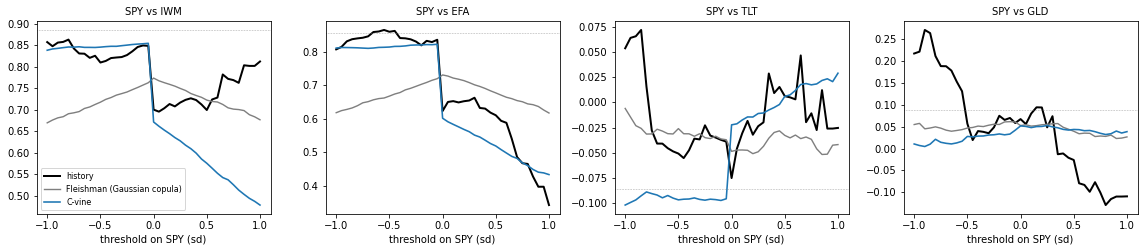

z = -1  z = 0  z = +1
IWM history      0.86   0.70    0.81
    Fleishman    0.67   0.77    0.68
    C-vine       0.84   0.67    0.48
EFA history      0.81   0.62    0.34
    Fleishman    0.62   0.73    0.62
    C-vine       0.81   0.60    0.43
TLT history      0.05  -0.07   -0.03
    Fleishman   -0.01  -0.05   -0.04
    C-vine      -0.10  -0.02    0.03
GLD history      0.22   0.07   -0.11
    Fleishman    0.05   0.05    0.03
    C-vine       0.01   0.05    0.04

In [11]:
pairs = ["IWM", "EFA", "TLT", "GLD"]; z = np.round(np.arange(-1, 1.0001, 0.05), 3)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, b in zip(axes, pairs):
    ax.plot(z, exceedance_curve(X["SPY"], X[b], z).values, color="black", lw=2, label="history")
    ax.plot(z, exceedance_curve(S["SPY"], S[b], z).values, color="tab:grey", lw=1.4, label="Fleishman (Gaussian copula)")
    ax.plot(z, exceedance_curve(C["SPY"], C[b], z).values, color="tab:blue", lw=1.6, label="C-vine")
    ax.axhline(t.corr.loc["SPY", b], color="grey", lw=0.6, ls=":"); ax.set_title(f"SPY vs {b}", fontsize=10); ax.set_xlabel("threshold on SPY (sd)")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()
rows = {}
for b in pairs:
    for name, D in [("history", X), ("Fleishman", S), ("C-vine", C)]:
        e = exceedance_curve(D["SPY"], D[b], [-1.0, 0.0, 1.0]); rows[(b, name)] = {"z = -1": e.iloc[0], "z = 0": e.iloc[1], "z = +1": e.iloc[2]}
pd.DataFrame(rows).T.round(2)

## Step 4: the two portfolios again

The global equity portfolio and the 60/40 of notebook 01, on the history, on
the benchmark and on the C-vine: skewness, kurtosis, VaR and expected
shortfall, and for the 60/40 the co-kurtosis of SPY and TLT. The reading is in
the cell that follows the table.

In [12]:
def var_es(r, alpha=0.05):
    q = np.quantile(r, alpha); return -q, -r[r <= q].mean()
ports = {"global equity (SPY, IWM, EFA)": {"SPY": 1 / 3, "IWM": 1 / 3, "EFA": 1 / 3}, "60/40 (SPY, TLT)": {"SPY": 0.6, "TLT": 0.4}}
rows = {}
for pn, pw in ports.items():
    w = pd.Series(pw).reindex(X.columns).fillna(0.0)
    for name, D in [("history", X), ("Fleishman", S), ("C-vine", C)]:
        r = (D @ w).values; v, e = var_es(r)
        rows[(pn, name)] = {"skewness": stats.skew(r), "kurtosis": stats.kurtosis(r) + 3, "VaR 5% (%)": v * 100, "ES 5% (%)": e * 100,
                            "co-kurtosis SPY,TLT": np.mean(z_(D["SPY"])**2 * z_(D["TLT"])**2) if "TLT" in pw else np.nan}
pd.DataFrame(rows).T.round(2)

skewness  kurtosis  VaR 5% (%)  ES 5% (%)  co-kurtosis SPY,TLT
global equity (SPY, IWM, EFA) history       -0.62      4.66        8.22      10.39                  NaN
                              Fleishman     -0.44      4.21        7.31      10.20                  NaN
                              C-vine        -0.65      4.56        7.50      10.73                  NaN
60/40 (SPY, TLT)              history       -0.68      5.02        4.51       6.53                 1.75
                              Fleishman     -0.31      3.80        4.22       5.92                 1.02
                              C-vine        -0.24      5.42        4.08       6.06                 2.27

### Reading the two portfolios

The equity portfolio is recovered. Its skewness and kurtosis on the C-vine
data are those of the history ($-0.65$ and 4.6 against $-0.62$ and 4.7), where
the benchmark had a third less skewness and a lower kurtosis, and its expected
shortfall is at the history's value (10.73 against 10.39, the benchmark 10.20).
The VaR remains below the history's: that gap was traced in notebook 01 to the
sampling noise of a quantile estimated on 13 months. What carries the
recovery is the two Gumbel copulas on the equity pairs, selected on the copula
scale, where SPY's own skewness cannot masquerade as dependence.

The 60/40 is half recovered, and the half that is not is instructive. The
kurtosis and the co-kurtosis are there, both above the history's: with 2.8
degrees of freedom the Student t makes the large moves of equity and
Treasuries coincide more than the sample shows, and the expected shortfall
moves toward the history's (6.06 against 6.53, benchmark 5.92). The skewness
is not there. The history's skewness on this portfolio comes from a
*co-skewness*, $\mathbb E[s\, b^2] = -0.48$, equity falling when Treasuries move
a lot in either direction, which is a directional feature of the pair. The
symmetry test found the asymmetry of SPY against TLT not distinguishable from
noise on 261 months ($0.00$, interval $[-0.24, 0.24]$) and gave the pair a
symmetric copula, which cannot produce co-skewness. That is the correct
statistical call, and it is a limit: a feature that 261 months do not identify
is not put into the synthetic data. Notebook 04 shows where part of it comes
from, the time variation of the volatilities, which this one-period view
cannot carry.

One more thing to read in the exceedance table: SPY against IWM is strongly
dependent on both sides in the history (0.86 in the bad months, 0.81 in the
good ones) with a mild asymmetry the test found significant; the Gumbel 180
reproduces the left side and, having no upper tail, under-reproduces the
right. A two-sided family with a stronger left side is not in the catalog.

The rule of notebook 01 holds: what is targeted is reproduced. The exceedance
profile and the co-movement of sizes are now targets, and they are matched
where the data identify them.

## Save

In [13]:
cv.save("tail_market.json")
CVineMarket.load("tail_market.json").simulate(5, seed=3, accept=False).round(4)

,SPY,IWM,EFA,TLT,IEF,GLD
0,0.0310,0.0373,0.0302,-0.0165,0.0173,0.1033
1,-0.0760,-0.1059,-0.0901,-0.0166,-0.0315,-0.0257
2,0.0317,0.0370,0.0307,-0.0050,0.0091,-0.0226
3,0.0297,0.0363,0.0295,0.0841,0.0207,-0.0256
4,0.0310,0.0377,0.0302,-0.0183,0.0024,0.0194


## What was learned, and what comes next

The dependence of a set of assets is a copula, and the Gaussian copula of
notebook 01 has none in the tails. The exceedance profile measures tail
dependence with a direction, the co-kurtosis without; the catalog of families
covers both, Clayton and Gumbel with their rotations for the first, the Student
t for the second; the symmetry test, on the copula scale, decides from the data which
case a pair is in, and the C-vine generator selects, calibrates and simulates
with the same moments and correlations as before. On the same
portfolio as notebook 01 it recovers the history's skewness, kurtosis and
expected shortfall; on the 60/40 it recovers the co-movement of sizes and not
the directional co-skewness the data do not identify. Both generators are kept from here on, the
Fleishman as the fast benchmark whose gap is the size of the tails.

**Notebook 03** meets the limit of doing this pair by pair: an asset manager's
universe has a hundred assets or more, and the answer is a few factors that
carry the dependence, with the assets mapped on them.